C:\Users\hp\AppData\Local\Temp\ipykernel_10508\878795228.py:24: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")


(1000098, 52)
Dataset Shape:
(1000098, 52)

First 5 Rows:
   UnderwrittenCoverID  PolicyID     TransactionMonth  IsVATRegistered  \
0               145249     12827  2015-03-01 00:00:00             True   
1               145249     12827  2015-05-01 00:00:00             True   
2               145249     12827  2015-07-01 00:00:00             True   
3               145255     12827  2015-05-01 00:00:00             True   
4               145255     12827  2015-07-01 00:00:00             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
2              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
4              Close Corporation    Mr  English  First National Bank   

       AccountType  ...                    ExcessSelected CoverC

c:\Users\hp\insurance-risk-analytics\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


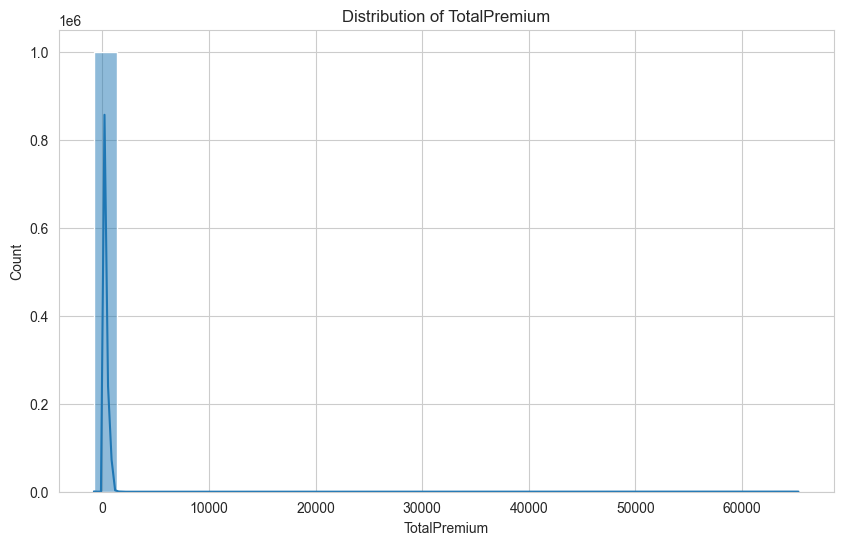

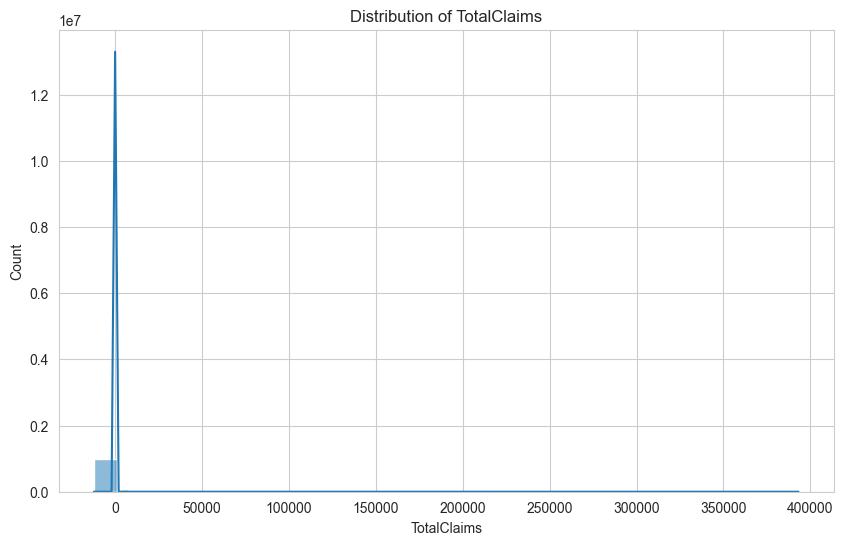

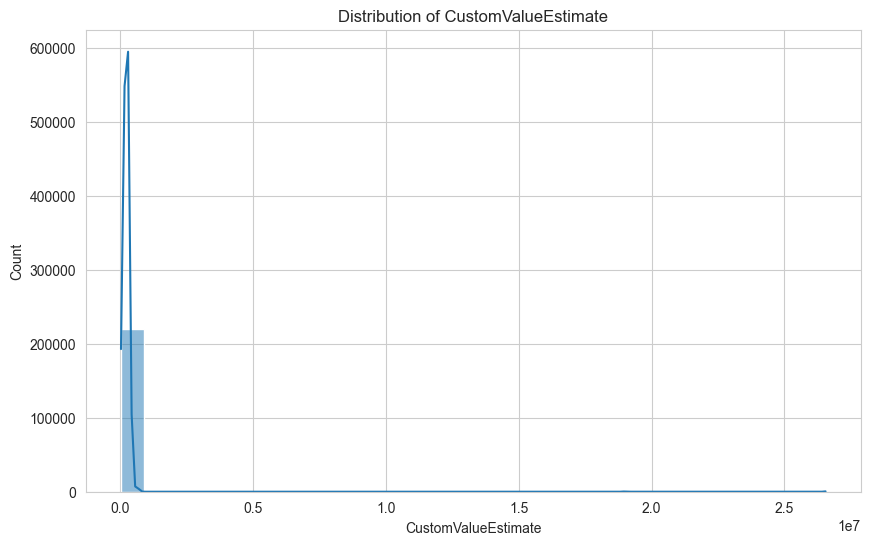

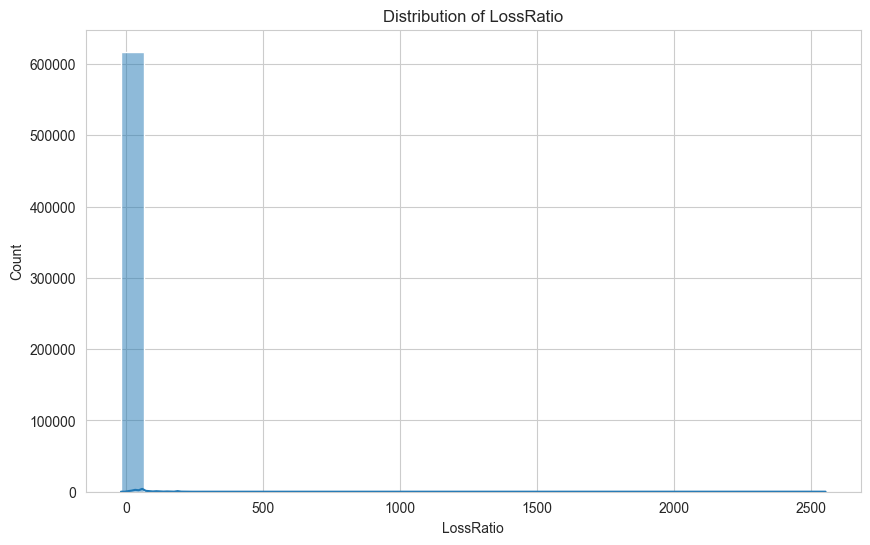

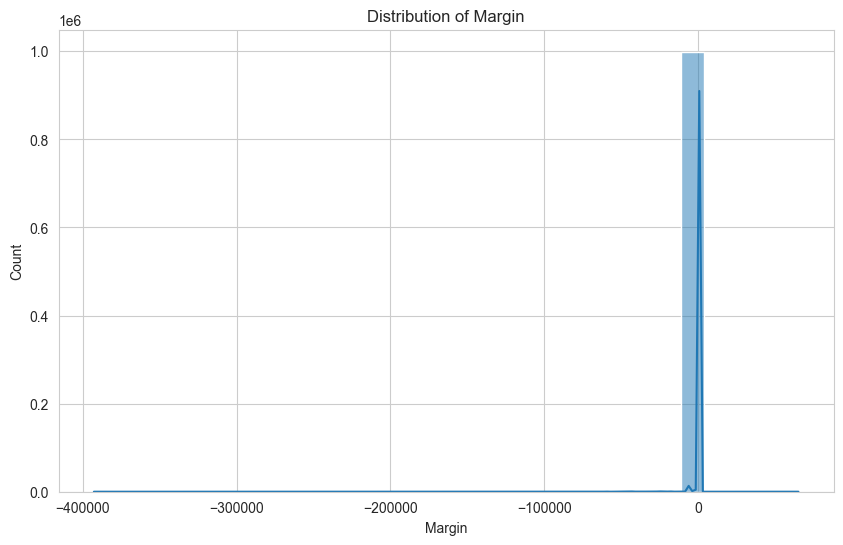

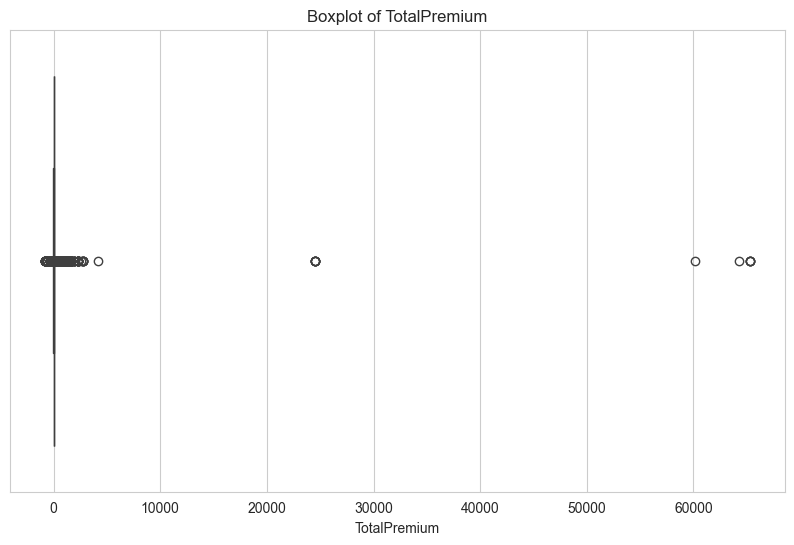

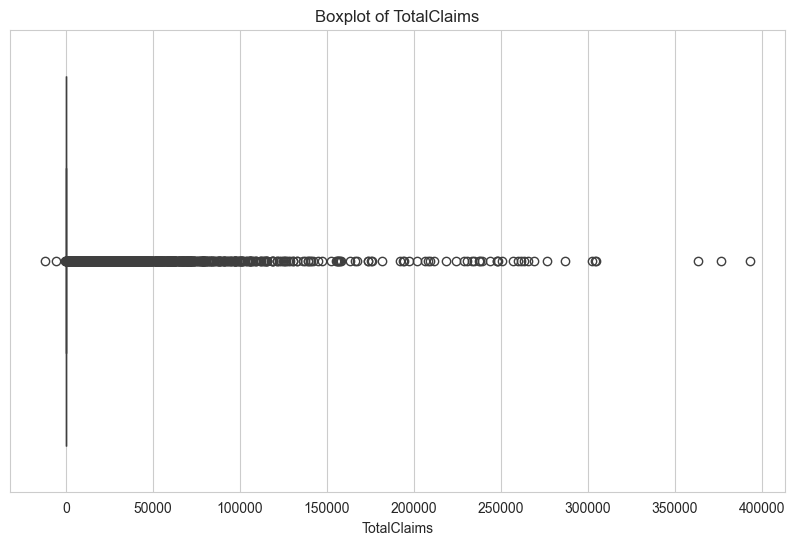

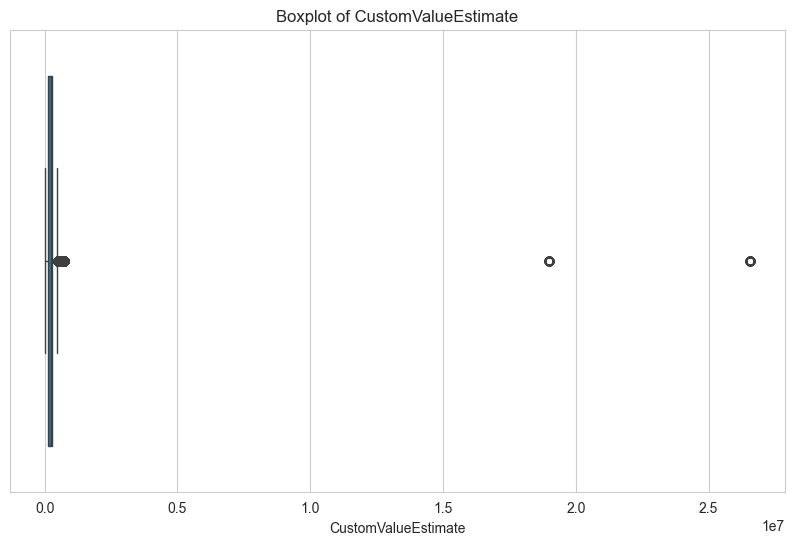

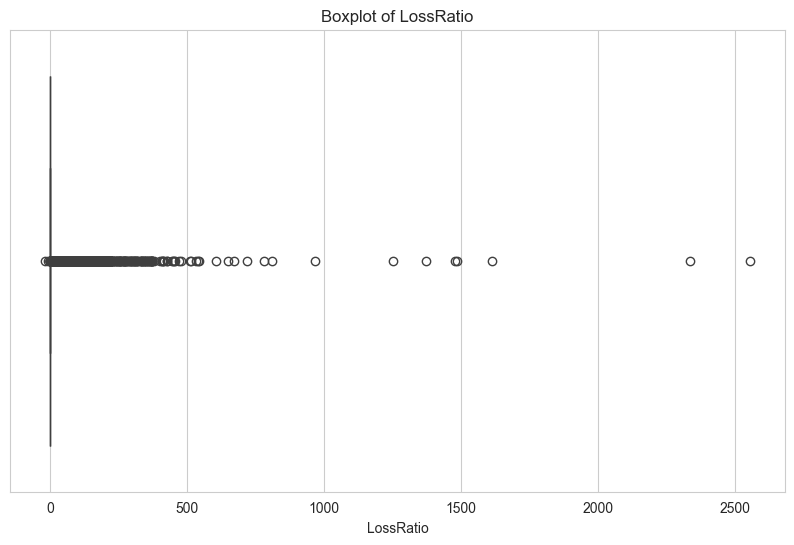

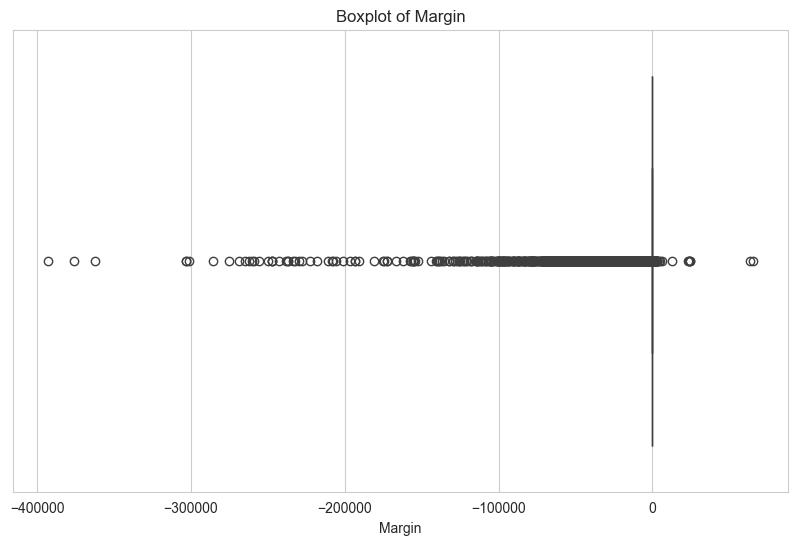

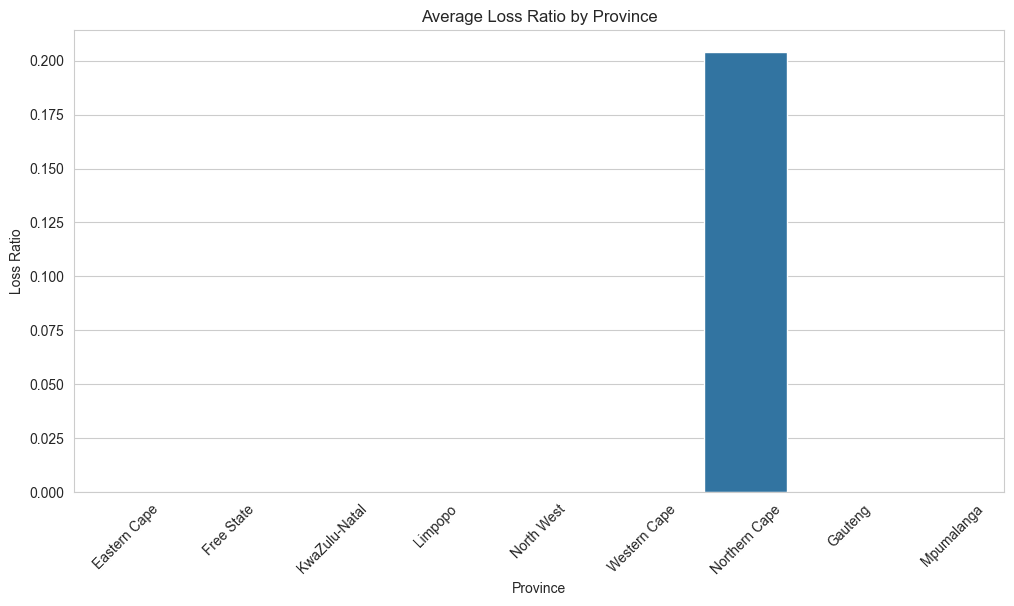

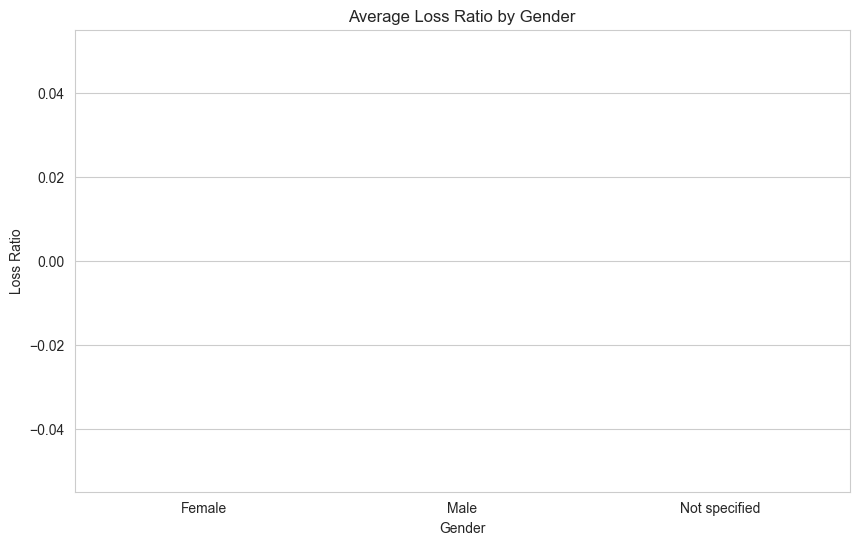

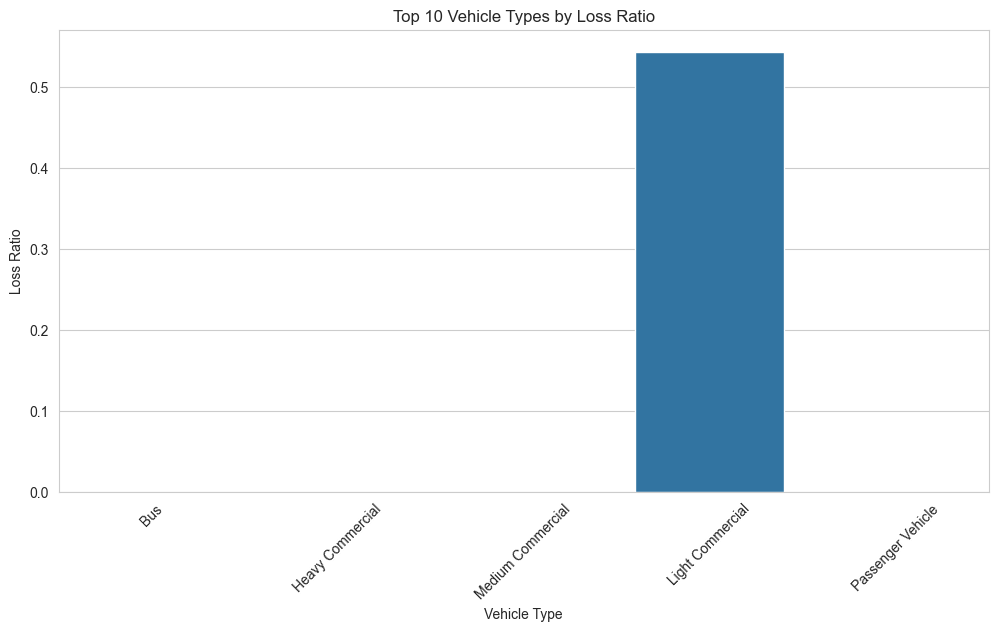

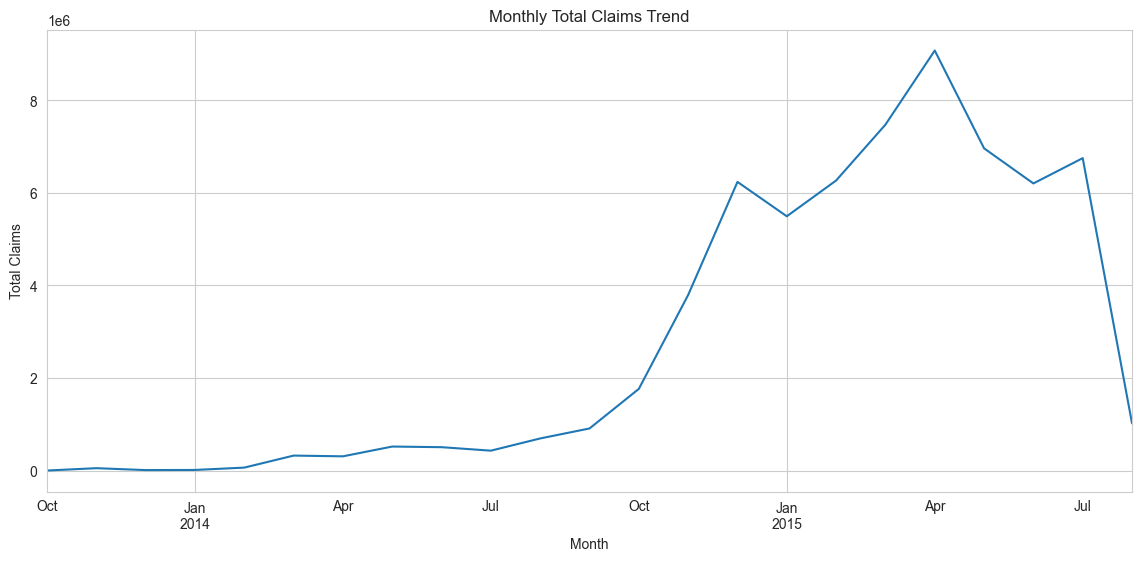

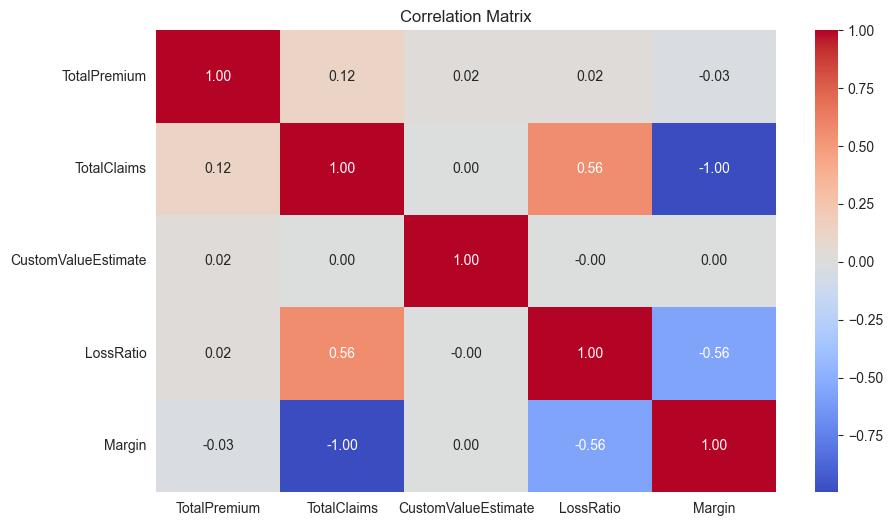


Key Insights:
- Loss ratio helps identify high-risk customer segments.
- Provinces with higher loss ratios may require premium adjustments.
- Outliers in TotalClaims can significantly impact profitability.
- Temporal trends reveal changes in claim behavior over time.
- Vehicle types with higher loss ratios represent higher insurance risk.


In [6]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_data
from eda_utils import calculate_loss_ratio, calculate_margin

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==============================
# LOAD DATA
# ==============================

df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")

print(df.shape)
df.head()

# ==============================
# BASIC OVERVIEW
# ==============================

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

# ==============================
# MISSING VALUES
# ==============================

missing_values = df.isnull().sum().sort_values(ascending=False)

print("\nMissing Values:")
print(missing_values[missing_values > 0])

cleaned_df = df.copy()

cleaned_df.to_csv(
    "../data/insurance_data_cleaned.csv",
    index=False
)

# ==============================
# FEATURE ENGINEERING
# ==============================

df = calculate_loss_ratio(df)
df = calculate_margin(df)

print("\nLoss Ratio and Margin Statistics:")
print(df[["LossRatio", "Margin"]].describe())

# ==============================
# NUMERICAL DISTRIBUTIONS
# ==============================

numerical_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "LossRatio",
    "Margin"
]

for col in numerical_cols:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.show()

# ==============================
# OUTLIER DETECTION
# ==============================

for col in numerical_cols:
    if col in df.columns:
        plt.figure()
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

# ==============================
# LOSS RATIO BY PROVINCE
# ==============================

if "Province" in df.columns:
    province_loss = (
        df.groupby("Province")["LossRatio"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=province_loss.index,
        y=province_loss.values
    )

    plt.xticks(rotation=45)
    plt.title("Average Loss Ratio by Province")
    plt.ylabel("Loss Ratio")
    plt.xlabel("Province")
    plt.show()

# ==============================
# LOSS RATIO BY GENDER
# ==============================

if "Gender" in df.columns:
    gender_loss = (
        df.groupby("Gender")["LossRatio"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure()
    sns.barplot(
        x=gender_loss.index,
        y=gender_loss.values
    )

    plt.title("Average Loss Ratio by Gender")
    plt.ylabel("Loss Ratio")
    plt.xlabel("Gender")
    plt.show()

# ==============================
# LOSS RATIO BY VEHICLE TYPE
# ==============================

if "VehicleType" in df.columns:
    vehicle_loss = (
        df.groupby("VehicleType")["LossRatio"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=vehicle_loss.index,
        y=vehicle_loss.values
    )

    plt.xticks(rotation=45)
    plt.title("Top 10 Vehicle Types by Loss Ratio")
    plt.ylabel("Loss Ratio")
    plt.xlabel("Vehicle Type")
    plt.show()

# ==============================
# TEMPORAL TREND ANALYSIS
# ==============================

if "TransactionMonth" in df.columns:

    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

    monthly_claims = (
        df.groupby("TransactionMonth")["TotalClaims"]
        .sum()
    )

    plt.figure(figsize=(14, 6))
    monthly_claims.plot()

    plt.title("Monthly Total Claims Trend")
    plt.ylabel("Total Claims")
    plt.xlabel("Month")
    plt.show()

# ==============================
# CORRELATION MATRIX
# ==============================

corr_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "LossRatio",
    "Margin"
]
available_corr_cols = [
    col for col in corr_cols if col in df.columns
]

corr_matrix = df[available_corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# ==============================
# BUSINESS INSIGHTS
# ==============================

print("\nKey Insights:")
print("- Loss ratio helps identify high-risk customer segments.")
print("- Provinces with higher loss ratios may require premium adjustments.")
print("- Outliers in TotalClaims can significantly impact profitability.")
print("- Temporal trends reveal changes in claim behavior over time.")
print("- Vehicle types with higher loss ratios represent higher insurance risk.")
